In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [3]:
df = pd.read_csv('ds_salaries.csv')
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [4]:
df.shape

(3755, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary              3755 non-null   int64 
 5   salary_currency     3755 non-null   object
 6   salary_in_usd       3755 non-null   int64 
 7   employee_residence  3755 non-null   object
 8   remote_ratio        3755 non-null   int64 
 9   company_location    3755 non-null   object
 10  company_size        3755 non-null   object
dtypes: int64(4), object(7)
memory usage: 322.8+ KB


In [6]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,3755.00,3755.00,3755.00,3755.00
mean,2022.37,190695.57,137570.39,46.27
std,0.69,671676.50,63055.63,48.59
min,2020.00,6000.00,5132.00,0.00
25%,2022.00,100000.00,95000.00,0.00
50%,2022.00,138000.00,135000.00,0.00
75%,2023.00,180000.00,175000.00,100.00
max,2023.00,30400000.00,450000.00,100.00


In [7]:
print('Number of duplicated rows: ', df.duplicated().sum())
print('Number of empty rows:\n', df.isnull().sum())

Number of duplicated rows:  1171
Number of empty rows:
 work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64


In [8]:
df = df.drop_duplicates(keep='first')

## **Data Vizualization**

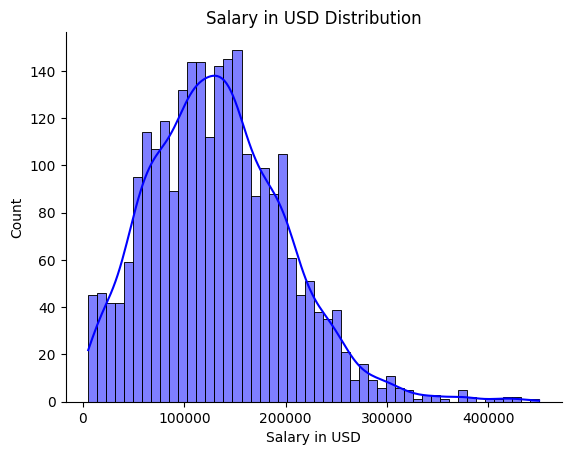

In [60]:
sns.histplot(data=df, x='salary_in_usd', bins=50, kde=True, color='blue')
plt.title('Salary in USD Distribution')
plt.xlabel('Salary in USD')
sns.despine()
plt.show()

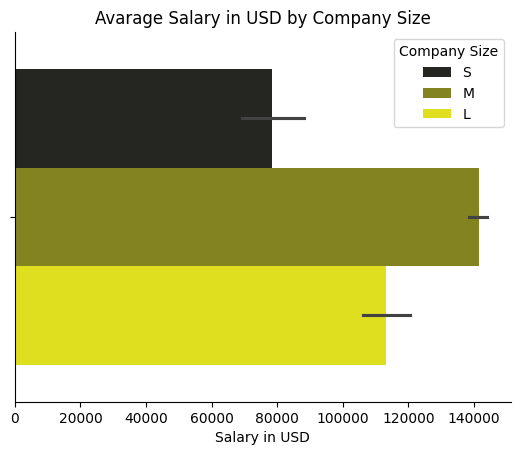

In [9]:
hue_order = ['S', 'M', 'L']
sns.barplot(data=df, x='salary_in_usd', hue='company_size', hue_order=hue_order, palette='dark:yellow')
plt.title('Avarage Salary in USD by Company Size')
plt.xlabel('Salary in USD')
plt.legend(title='Company Size')
sns.despine()
plt.show()

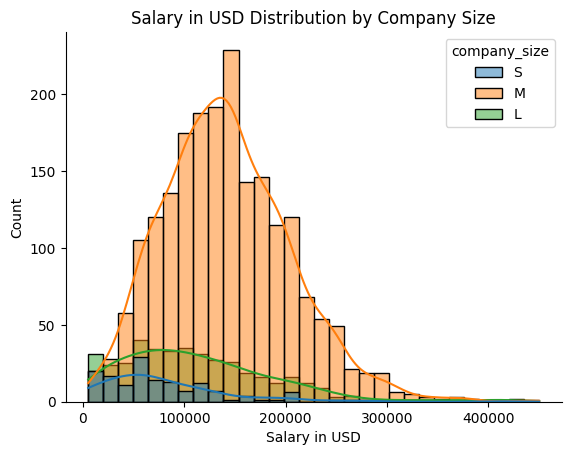

In [10]:
hue_order = ['S', 'M', 'L']
sns.histplot(data=df, x='salary_in_usd', hue='company_size', bins=30, kde=True, hue_order=hue_order, color='green')
plt.title('Salary in USD Distribution by Company Size')
plt.xlabel('Salary in USD')
sns.despine()
plt.show()

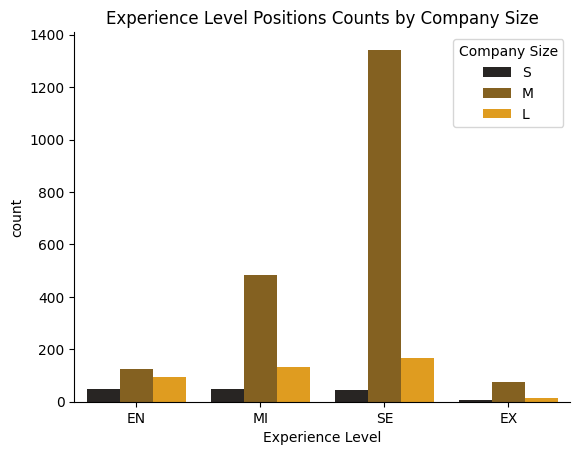

In [61]:
order = ['EN', 'MI', 'SE', 'EX']
hue_order = ['S', 'M', 'L']
sns.countplot(data=df, x='experience_level', hue='company_size', palette='dark:orange', order=order, hue_order=hue_order)
plt.title('Experience Level Positions Counts by Company Size')
plt.xlabel('Experience Level')
plt.legend(title='Company Size')
sns.despine()
plt.show()

C:\Users\42060\AppData\Local\Temp\ipykernel_4808\1586839594.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_top, y='salary_in_usd', x='company_location',
C:\Users\42060\AppData\Local\Temp\ipykernel_4808\1586839594.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top, y='salary_in_usd', x='company_location',


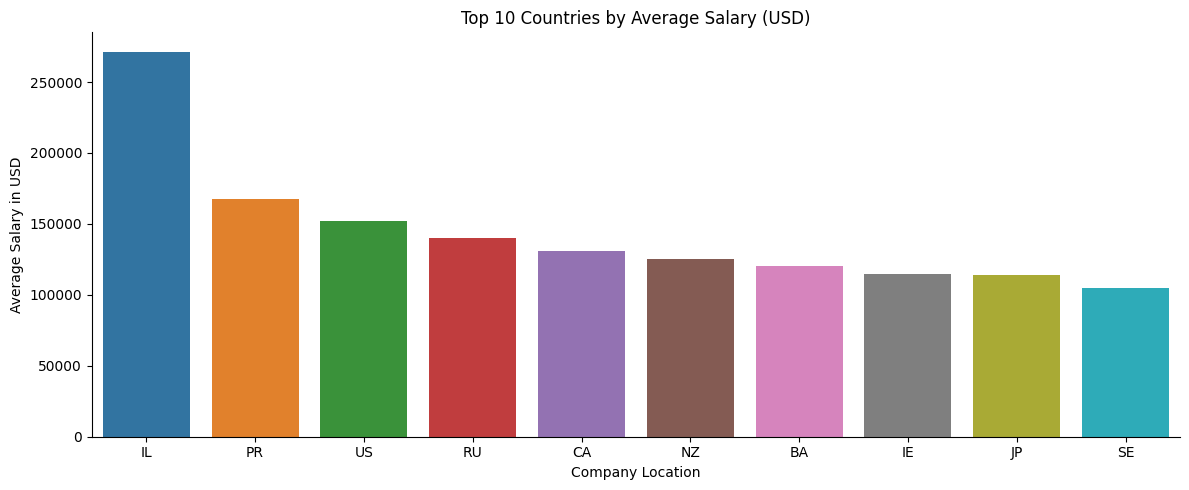

In [50]:
top_countries = df.groupby('company_location')['salary_in_usd'].mean().sort_values(ascending=False).head(10)
df_top = df[df['company_location'].isin(top_countries.index)]

plt.figure(figsize=(12, 5))
sns.barplot(data=df_top, y='salary_in_usd', x='company_location',
            order=top_countries.index, ci=None, palette=sns.color_palette('tab10', n_colors=10))
plt.title('Top 10 Countries by Average Salary (USD)')
plt.xlabel('Company Location')
plt.ylabel('Average Salary in USD')
sns.despine()
plt.tight_layout()
plt.show()

C:\Users\42060\AppData\Local\Temp\ipykernel_4808\2830910916.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_worst, y='salary_in_usd', x='company_location',
C:\Users\42060\AppData\Local\Temp\ipykernel_4808\2830910916.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_worst, y='salary_in_usd', x='company_location',


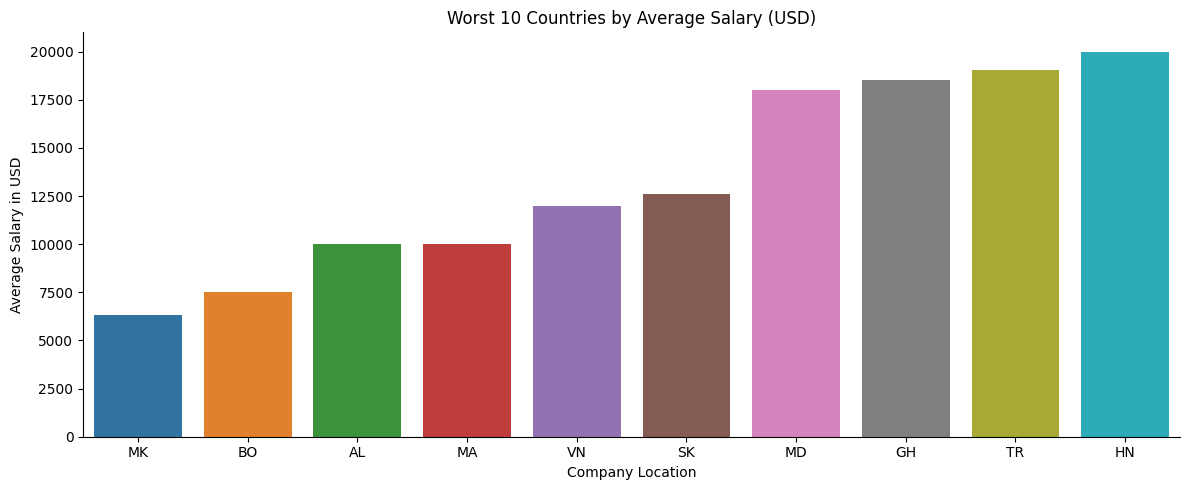

In [51]:
worst_countries = df.groupby('company_location')['salary_in_usd'].mean().sort_values(ascending=True).head(10)
df_worst = df[df['company_location'].isin(worst_countries.index)]

plt.figure(figsize=(12, 5))
sns.barplot(data=df_worst, y='salary_in_usd', x='company_location',
            order=worst_countries.index, ci=None, palette=sns.color_palette('tab10', n_colors=10))
plt.title('Worst 10 Countries by Average Salary (USD)')
plt.xlabel('Company Location')
plt.ylabel('Average Salary in USD')
sns.despine()
plt.tight_layout()
plt.show()

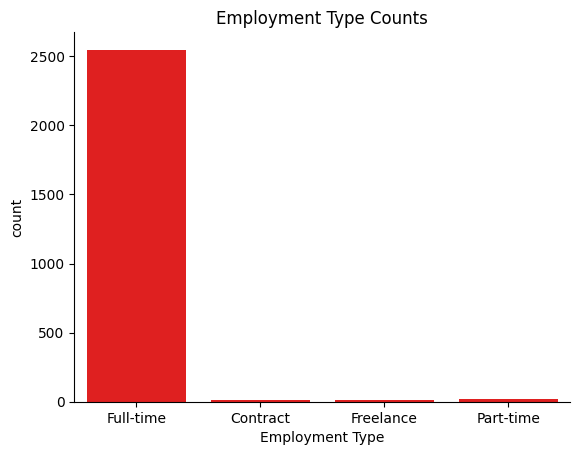

In [47]:
order = ['Part-time', 'Full-time', 'Contract', 'Freelance']

sns.countplot(data=df, x='employment_type', color='red')
plt.title('Employment Type Counts')
plt.xlabel('Employment Type')
sns.despine()
plt.show()

C:\Users\42060\AppData\Local\Temp\ipykernel_4808\130601609.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='employment_type', y='salary_in_usd', ci=None, order=order, color='green')


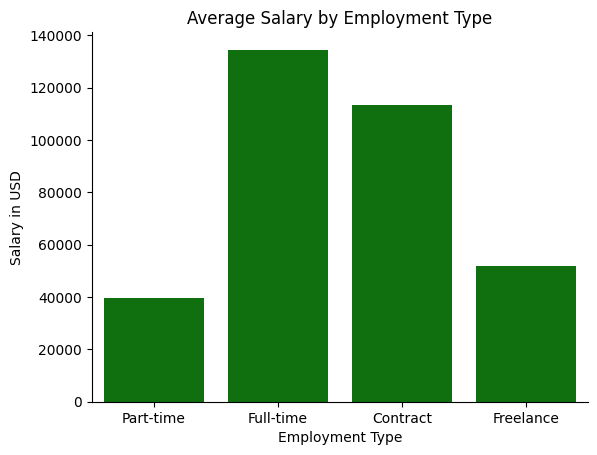

In [39]:
types = {
    'PT' : 'Part-time',
    'FT' : 'Full-time',
    'CT' : 'Contract',
    'FL' : 'Freelance'
}
df.employment_type = df.employment_type.replace(types)
order = ['Part-time', 'Full-time', 'Contract', 'Freelance']

sns.barplot(data=df, x='employment_type', y='salary_in_usd', ci=None, order=order, color='green')
plt.title('Average Salary by Employment Type')
sns.despine()
plt.xlabel('Employment Type')
plt.ylabel('Salary in USD')
plt.show()

C:\Users\42060\AppData\Local\Temp\ipykernel_4808\4241028328.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='remote_ratio', y='salary_in_usd', ci=None, color='yellow')


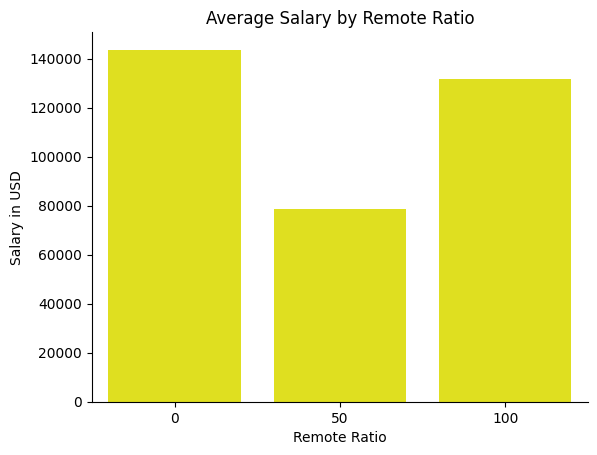

In [42]:
sns.barplot(data=df, x='remote_ratio', y='salary_in_usd', ci=None, color='yellow')
plt.title('Average Salary by Remote Ratio')
sns.despine()
plt.xlabel('Remote Ratio')
plt.ylabel('Salary in USD')
plt.show()

C:\Users\42060\AppData\Local\Temp\ipykernel_4808\1150602664.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_top, y='salary_in_usd', x='employee_residence',
C:\Users\42060\AppData\Local\Temp\ipykernel_4808\1150602664.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top, y='salary_in_usd', x='employee_residence',


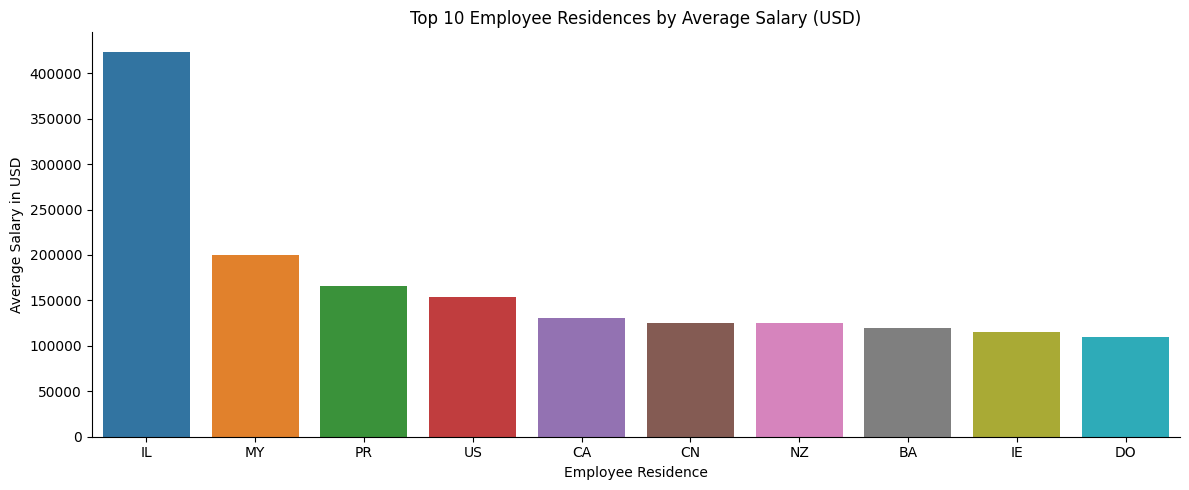

In [46]:
top_residence = df.groupby('employee_residence')['salary_in_usd'].mean().sort_values(ascending=False).head(10)
df_top = df[df['employee_residence'].isin(top_residence.index)]

plt.figure(figsize=(12, 5))
sns.barplot(data=df_top, y='salary_in_usd', x='employee_residence',
            order=top_residence.index, ci=None, palette=sns.color_palette('tab10', n_colors=10))
plt.title('Top 10 Employee Residences by Average Salary (USD)')
plt.xlabel('Employee Residence')
plt.ylabel('Average Salary in USD')
sns.despine()
plt.tight_layout()
plt.show()

C:\Users\42060\AppData\Local\Temp\ipykernel_4808\1673701998.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='work_year', y='salary_in_usd', ci=None, color='pink')


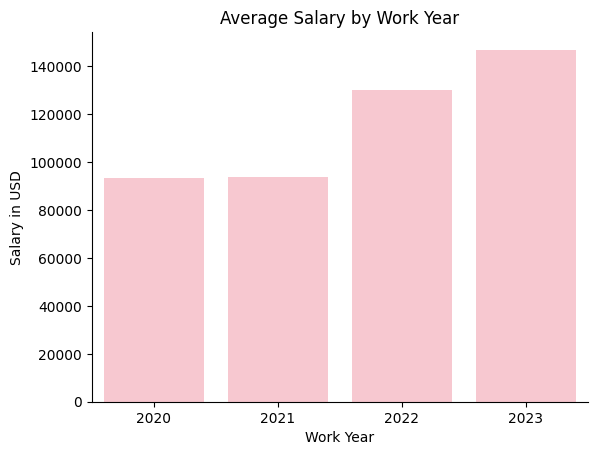

In [53]:
sns.barplot(data=df, x='work_year', y='salary_in_usd', ci=None, color='pink')
plt.title('Average Salary by Work Year')
sns.despine()
plt.xlabel('Work Year')
plt.ylabel('Salary in USD')
plt.show()

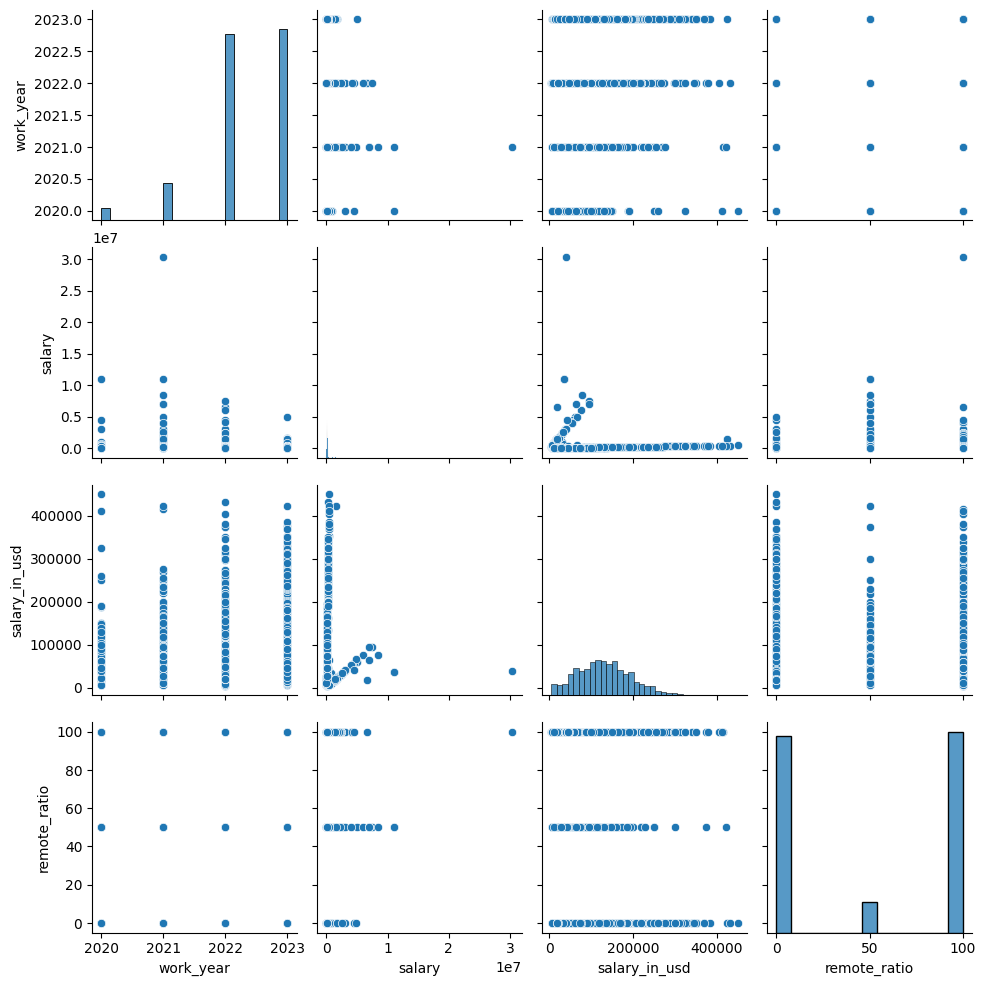

In [52]:
sns.pairplot(df)

<AxesSubplot: >

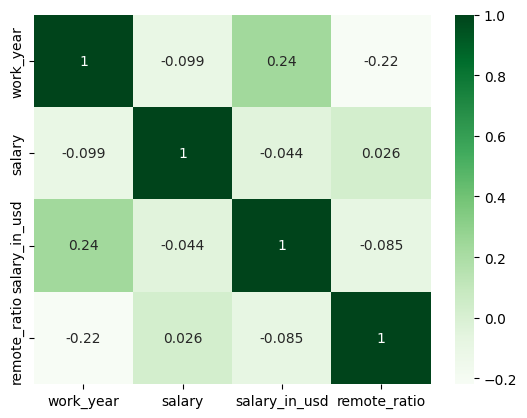

In [64]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Greens')

C:\Users\42060\AppData\Local\Temp\ipykernel_4808\899197670.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_top, y='salary_in_usd', x='job_title',
C:\Users\42060\AppData\Local\Temp\ipykernel_4808\899197670.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top, y='salary_in_usd', x='job_title',


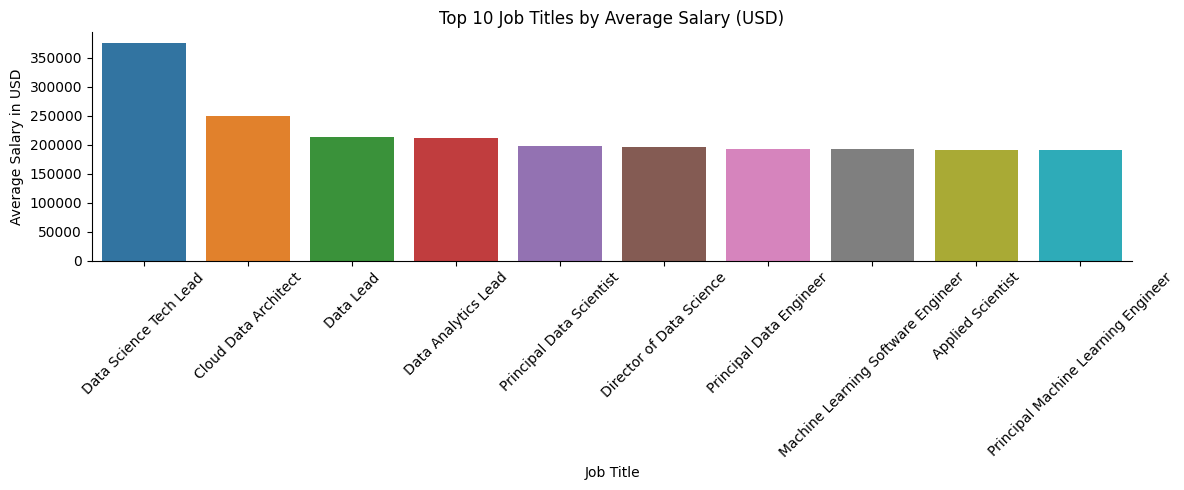

In [67]:
top_title = df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False).head(10)
df_top = df[df['job_title'].isin(top_title.index)]

plt.figure(figsize=(12, 5))
sns.barplot(data=df_top, y='salary_in_usd', x='job_title',
            order=top_title.index, ci=None, palette=sns.color_palette('tab10', n_colors=10))
plt.title('Top 10 Job Titles by Average Salary (USD)')
plt.xlabel('Job Title')
plt.ylabel('Average Salary in USD')
sns.despine()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\42060\AppData\Local\Temp\ipykernel_4808\256136872.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_worst, y='salary_in_usd', x='job_title',
C:\Users\42060\AppData\Local\Temp\ipykernel_4808\256136872.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_worst, y='salary_in_usd', x='job_title',


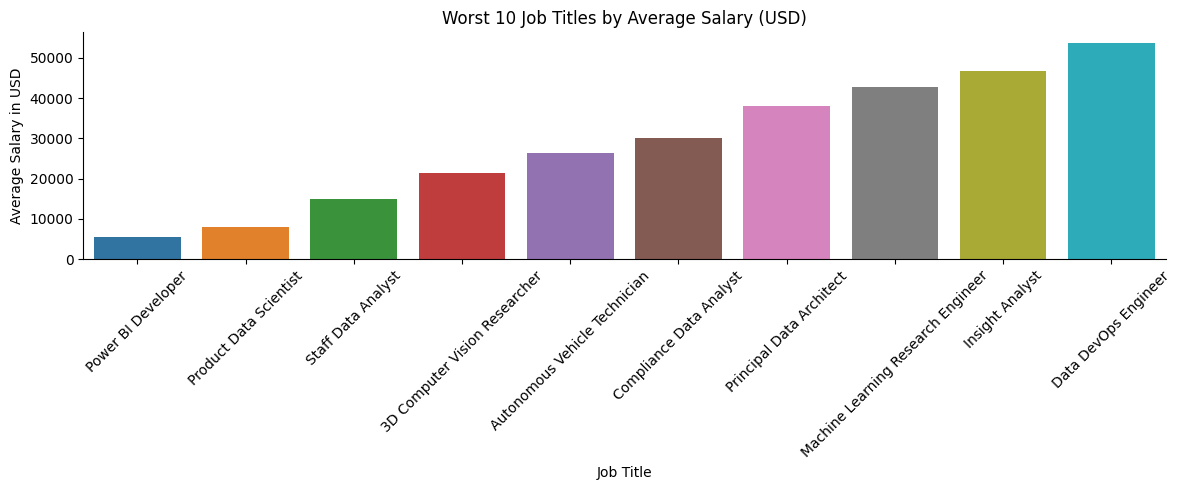

In [70]:
worst_title = df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=True).head(10)
df_worst = df[df['job_title'].isin(worst_title.index)]

plt.figure(figsize=(12, 5))
sns.barplot(data=df_worst, y='salary_in_usd', x='job_title',
            order=worst_title.index, ci=None, palette=sns.color_palette('tab10', n_colors=10))
plt.title('Worst 10 Job Titles by Average Salary (USD)')
plt.xlabel('Job Title')
plt.ylabel('Average Salary in USD')
sns.despine()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Predictive Modelling**

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2584 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           2584 non-null   int64 
 1   experience_level    2584 non-null   object
 2   employment_type     2584 non-null   object
 3   job_title           2584 non-null   object
 4   salary              2584 non-null   int64 
 5   salary_currency     2584 non-null   object
 6   salary_in_usd       2584 non-null   int64 
 7   employee_residence  2584 non-null   object
 8   remote_ratio        2584 non-null   int64 
 9   company_location    2584 non-null   object
 10  company_size        2584 non-null   object
dtypes: int64(4), object(7)
memory usage: 242.2+ KB


In [77]:
from sklearn.model_selection import train_test_split

num_features = ['salary']
cat_features = df.drop(['salary', 'salary_in_usd'], axis=1).columns.tolist()

X = df[num_features + cat_features]
y = df['salary_in_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [78]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

## **1. Linear Regression**

In [112]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
model=Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', reg)
])
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['salary']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['work_year',
                                                   'experience_level',
                                                   'employment_type',
                                                   'job_title',
                                                   'salary_currency',
                                                   'employee_residence',
                                                   'remote_ratio',
                                                   'company_location',
                                                   'company_size'])])),
                ('regressor', LinearRegression())])

In [113]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mae_pct = (mae / df['salary_in_usd'].mean()) * 100
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae:.2f}')
print(f'MAE in %: {mae_pct:.2f}')
print(f'R2 Score: {r2:.2f}')

Mean Absolute Error: 38215.10
MAE in %: 28.65
R2 Score: 0.38


## **2. Random Forest**

In [88]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

reg = RandomForestClassifier(n_estimators=100, random_state=42)
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', reg)
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['salary']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['work_year',
                                                   'experience_level',
                                                   'employment_type',
                                                   'job_title',
                                                   'salary_currency',
                                                   'employee_residence',
                                                   'remote_ratio',
                                                   'company_location',
                                                   'company_size'])])),
                ('regressor', RandomForestClassifier(random_state=42))])

In [89]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mae_pct = (mae / df["salary_in_usd"].mean()) * 100
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae:.2f}')
print(f'MAE in %: {mae_pct:.2f}')
print(f'R2 Score: {r2:.2f}')

Mean Absolute Error: 15705.16
MAE in %: 11.77
R2 Score: 0.78


## **3. XGBoost**

In [91]:
from xgboost import XGBRegressor

reg = XGBRegressor(eval_metric='mae', random_state=42)
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', reg)
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['salary']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['work_year',
                                                   'experience_level',
                                                   'employment_type',
                                                   'job_title',
                                                   'salary_currency',
                                                   'employee_residence',
                                                   'remote_ratio',
                                                   'company_location',
                                                   'company_size'])])),
                ('regressor',
                 XGBRegressor(base_score=None, booster...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [92]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mae_pct = (mae / df['salary_in_usd'].mean()) * 100
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae:.2f}')
print(f'MAE in %: {mae_pct:.2f}')
print(f'R2 Score: {r2:.2f}')

Mean Absolute Error: 2339.17
MAE in %: 1.75
R2 Score: 0.95


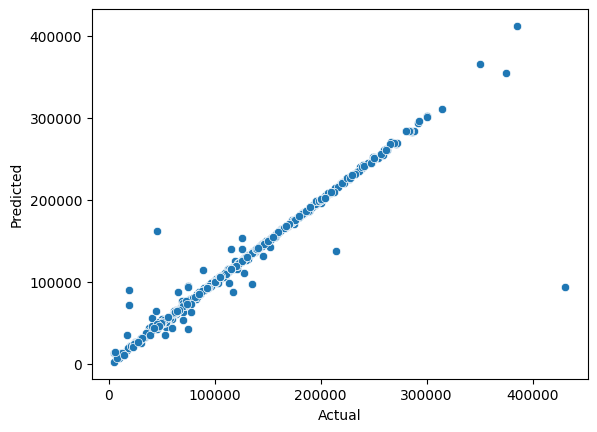

In [99]:
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

### **Feature Importance:**

C:\Users\42060\AppData\Local\Temp\ipykernel_4808\2425373668.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df.head(10), x="Importance", y="Feature", palette="viridis")


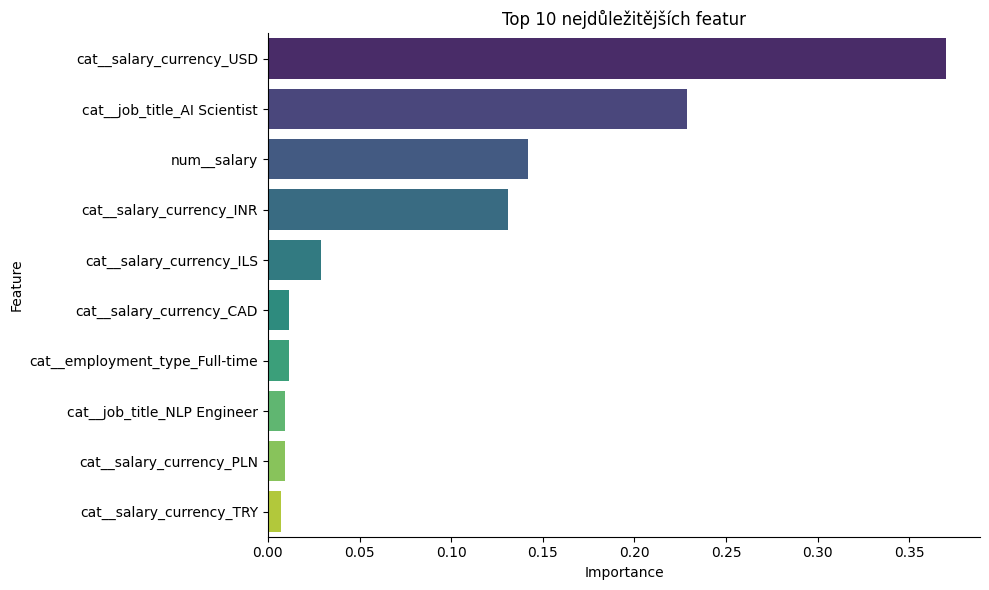

In [104]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
importances = model.named_steps['regressor'].feature_importances_
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df.head(10), x="Importance", y="Feature", palette="viridis")
plt.title("Top 10 nejdůležitějších featur")
plt.tight_layout()
sns.despine()
plt.show()

## **Model Comparison**

C:\Users\42060\AppData\Local\Temp\ipykernel_4808\1058649007.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=mod_df, x='Model', y='R2 Score', ci=None, palette='viridis')
C:\Users\42060\AppData\Local\Temp\ipykernel_4808\1058649007.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mod_df, x='Model', y='R2 Score', ci=None, palette='viridis')


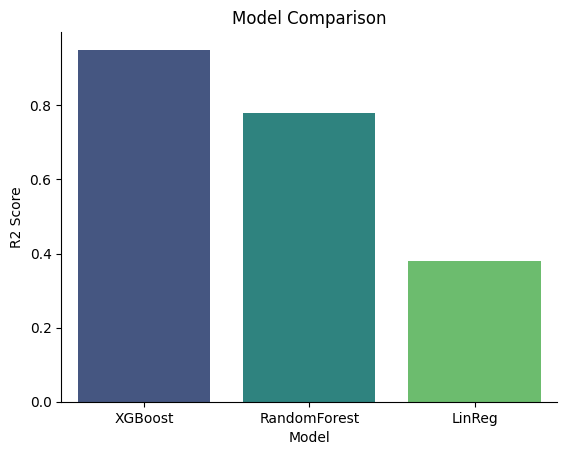

In [117]:
models = ['LinReg', 'RandomForest', 'XGBoost']
r2 = [0.38, 0.78, 0.95]
mod_df = pd.DataFrame({'Model': models, 'R2 Score': r2}).sort_values(by='R2 Score', ascending=False)

sns.barplot(data=mod_df, x='Model', y='R2 Score', ci=None, palette='viridis')
plt.title('Model Comparison')
sns.despine()
plt.show()